## 🎓 Student Information

- **Nama Lengkap:** Ranu Ratmaja
- **NIM:** 230401010104
- **Kelas:** IF401 - Data Science (PJJ S1 Informatika)
- **Universitas:** Universitas Siber Asia (UNSIA)

---


<a href="https://colab.research.google.com/github/RanzCoder119/MK_DataScience_2026/blob/main/Pertemuan10_RANU_RATMAJA_230401010104.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practice 10 - Algoritma Klasifikasi (Bagian 2)

## 🎓 Student Information

- **Name:** Ranu Ratmaja  
- **NIM:** 230401010104  
- **University:** UNSIA - Universitas Siber Asia  
- **Prodi:** PJJ - S1 Informatika  
- **Class:** IF401 Data Science


## Import Library & Setup


In [1]:
# Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_curve, roc_auc_score, precision_recall_curve)

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
print('✅ Library berhasil di-import')


✅ Library berhasil di-import


## 1. Konsep Ensemble Learning

Pada Pertemuan 9 kita telah membangun dua model klasifikasi "single learner" — Logistic Regression dan Decision Tree. Namun di praktik nyata, model tunggal seringkali memiliki variance yang tinggi (overfit pada data training) atau bias yang kuat (underfit). **Ensemble Learning** mengatasi masalah ini dengan **menggabungkan banyak model lemah** menjadi satu model kuat.

### 1.1 Filosofi: Wisdom of the Crowd

> *"Sebuah kelompok yang beragam sering kali menghasilkan keputusan kolektif yang lebih baik daripada keputusan satu ahli terbaik."*

Ide ini diadopsi oleh Random Forest: alih-alih mengandalkan satu Decision Tree, algoritma membangun ratusan pohon dari subset data yang berbeda, lalu menggabungkan suara mereka melalui **voting** (klasifikasi) atau **averaging** (regresi).

### 1.2 Dua Pendekatan Ensemble Utama

| Pendekatan | Metode Populer | Cara Kerja |
|------------|---------------|-----------|
| **Bagging** (Bootstrap Aggregating) | Random Forest | Train N pohon secara paralel pada bootstrap samples; hasil digabung dengan voting |
| **Boosting** | XGBoost, AdaBoost, GradientBoosting | Train pohon secara sekuensial; setiap pohon baru memperbaiki kesalahan pohon sebelumnya |

### 1.3 Kenapa Random Forest?

Random Forest menggabungkan **bagging** dengan **random feature selection** pada setiap split. Dua sumber keacakan ini menghasilkan koleksi pohon yang **decorrelated**, sehingga variance rata-rata ensemble turun drastis.

Keunggulan utama:
- Robust terhadap outlier dan fitur tidak relevan
- Memberikan estimasi **feature importance** gratis
- Bekerja baik pada data campuran (numerik + kategorik)
- Hyperparameter default-nya seringkali sudah cukup baik


### 1.2.B Visual: Bagging vs Boosting

```
   BAGGING (Paralel)                  BOOSTING (Sekuensial)
   ─────────────────                  ─────────────────────

     ┌────────┐                          ┌────────┐
   ┌─┤ Tree 1 │                          │ Tree 1 ├─┐
   │ └────────┘                          └────────┘ │ err₁
   │       ↑                                  ↓      │
   │    Bootstrap 1                       ┌────────┐ │
   │       ↑                              │ Tree 2 ├─┤  weight err₁
   │     Data                             └────────┘ │
   │                                          ↓      │
   │     ┌────────┐                       ┌────────┐ │
   ├─►   │ Tree 2 │  ← paralel            │ Tree 3 ├─┘  fokus sampel salah
   │     └────────┘                       └────────┘
   │       ↑                                  ↓
   │    Bootstrap 2                       Final: Σ wᵢ·treeᵢ
   │
   │     ┌────────┐
   └─►   │ Tree N │
         └────────┘
              ↓
         Voting / Averaging

   ✅ Reduce variance                 ✅ Reduce bias
   ✅ Robust terhadap outlier         ⚠ Sensitif terhadap outlier
   ✅ Mudah di-paralelkan             ❌ Sulit di-paralelkan
   Contoh: Random Forest              Contoh: XGBoost, AdaBoost, GBM
```


### 1.1.B Visual: Single Learner vs Ensemble

```
┌─────────────────────────────────────────────────────────────────────────┐
│                    SINGLE LEARNER (Model Tunggal)                       │
│                                                                         │
│        ┌─────────┐                                                     │
│  Data ─►│  Tree A ├─► Prediction                                       │
│        └─────────┘                                                     │
│   ↑                                                                   │
│   └── Variance tinggi → overfit risk                                  │
└─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│                       ENSEMBLE (Random Forest)                          │
│                                                                         │
│        ┌─────────┐                                                     │
│   D1 ──►│  Tree 1 ├─┐                                                  │
│        ├─────────┤ │     ┌──────────┐                                  │
│   D2 ──►│  Tree 2 ├─┼────►│  Voting  ├─► Final Prediction              │
│        ├─────────┤ │     └──────────┘                                  │
│   D3 ──►│  Tree 3 ├─┤              ↑                                   │
│        ├─────────┤ │     Variance turun → generalisasi lebih baik      │
│   Dn ──►│  Tree N ├─┘                                                  │
│        └─────────┘                                                     │
└─────────────────────────────────────────────────────────────────────────┘
   D1, D2, ..., Dn = Bootstrap samples (sampling with replacement)
```

<div style="background:#e8f4f8; padding:12px; border-left:4px solid #2A9D8F; border-radius:4px;">
💡 <b>Intuisi</b>: Bayangkan meminta 1 orang menebak jumlah kelereng dalam toples — mungkin meleset. Tapi jika Anda meminta 100 orang menebak lalu mengambil rata-rata, jawabannya jauh lebih akurat. Itulah esensi Random Forest.
</div>


## 2. Naive Bayes — Pendekatan Probabilistik

Sebagai pembanding ensemble modern, kita juga akan mengimplementasikan **Naive Bayes** — algoritma probabilistik berbasis Teorema Bayes dengan asumsi independensi antar fitur (asumsi "naive").

### 2.1 Teorema Bayes

$$P(y \mid X) = \frac{P(X \mid y) \cdot P(y)}{P(X)}$$

Karena $P(X)$ konstan untuk semua kelas, kita fokus pada pembilang:

$$P(y \mid X) \propto P(y) \cdot \prod_{i=1}^{n} P(x_i \mid y)$$

### 2.2 Varian Naive Bayes

| Varian | Asumsi Distribusi | Cocok untuk |
|--------|-------------------|-------------|
| **Gaussian NB** | Fitur kontinu ~ Normal | Default untuk data numerik |
| **Multinomial NB** | Fitur = frekuensi/count | Klasifikasi teks (TF-IDF/BoW) |
| **Bernoulli NB** | Fitur biner 0/1 | Klasifikasi teks biner |

### 2.3 Kelebihan & Kekurangan

✅ Cepat dilatih, bekerja baik pada dimensi tinggi (teks)  
✅ Cocok untuk data kecil  
❌ Asumsi independensi sering dilanggar di dunia nyata  
❌ Estimasi probabilitas kurang terkalibrasi


## 3. Dataset — Telco Customer Churn

Kita akan menggunakan dataset **Telco Customer Churn** yang berisi data 7.043 pelanggan provider telekomunikasi. Target: memprediksi apakah pelanggan akan **churn** (berhenti berlangganan) atau tidak.

### 3.1 Deskripsi Kolom

| Kategori | Kolom |
|----------|-------|
| **Identitas** | `customerID` (akan di-drop) |
| **Demografi** | `gender`, `SeniorCitizen`, `Partner`, `Dependents` |
| **Layanan** | `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` |
| **Akun** | `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges` |
| **Target** | `Churn` (Yes/No) |

### 3.2 Mengapa Kasus Churn Penting?

Di industri telekomunikasi, biaya akuisisi pelanggan baru bisa **5–7× lebih mahal** daripada mempertahankan pelanggan eksisting. Model prediksi churn yang akurat memungkinkan tim retention:
- Mengidentifikasi pelanggan berisiko tinggi **sebelum** mereka pergi
- Memberikan penawaran/promo terpersonalisasi
- Mengoptimalkan ROI program retensi


## 4. Load & Eksplorasi Data


In [2]:
# Load Dataset Telco Customer Churn
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print(f'Shape dataset  : {df.shape}')
print(f'Jumlah baris   : {df.shape[0]:,} pelanggan')
print(f'Jumlah kolom   : {df.shape[1]} fitur')
print()
print('Distribusi Target (Churn):')
churn_dist = df["Churn"].value_counts(normalize=True).round(3) * 100
for label, pct in churn_dist.items():
    print(f'  {label:4s} : {pct:.1f}%')
print()
df.head()


Shape dataset  : (7043, 21)
Jumlah baris   : 7,043 pelanggan
Jumlah kolom   : 21 fitur

Distribusi Target (Churn):
  No   : 73.5%
  Yes  : 26.5%



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Cek tipe data & missing values
print('=' * 55)
print('INFO DATASET')
print('=' * 55)
print(df.info())
print()
print('Missing values per kolom:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else '  Tidak ada missing value eksplisit')
print()
print('Statistik deskriptif kolom numerik:')
print(df.describe().round(2))


INFO DATASET
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str   

## 5. Exploratory Data Analysis (EDA)


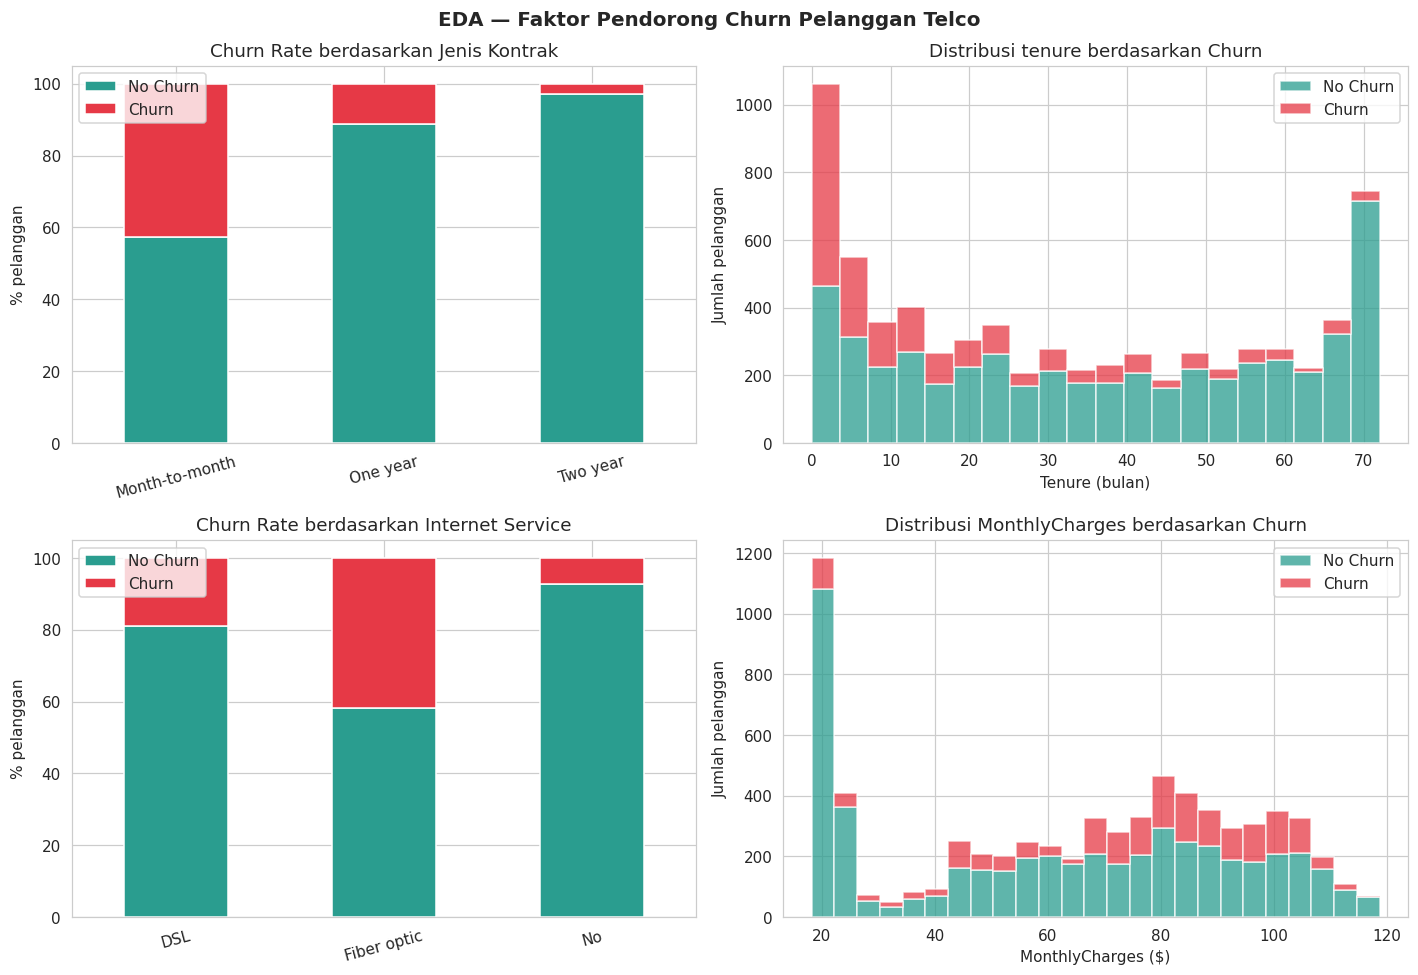


=== Insight Kuantitatif ===
Churn rate kontrak Month-to-month : 42.7%
Churn rate kontrak One/Two year   : 6.8%
Rata-rata tenure pelanggan churn  : 18.0 bulan
Rata-rata tenure pelanggan setia  : 37.6 bulan


In [4]:
# EDA — Visualisasi distribusi churn vs fitur kunci
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('EDA — Faktor Pendorong Churn Pelanggan Telco', fontsize=13, fontweight='bold')

# 1. Churn vs Contract type
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', stacked=True, ax=axes[0, 0], color=['#2A9D8F', '#E63946'])
axes[0, 0].set_title('Churn Rate berdasarkan Jenis Kontrak')
axes[0, 0].set_ylabel('% pelanggan')
axes[0, 0].set_xlabel('')
axes[0, 0].legend(['No Churn', 'Churn'])
axes[0, 0].tick_params(axis='x', rotation=15)

# 2. Churn vs tenure (lama berlangganan)
df_plot = df.copy()
df_plot['Churn_num'] = (df_plot['Churn'] == 'Yes').astype(int)
axes[0, 1].hist([df_plot[df_plot['Churn']=='No']['tenure'],
                  df_plot[df_plot['Churn']=='Yes']['tenure']],
                bins=20, label=['No Churn', 'Churn'],
                color=['#2A9D8F', '#E63946'], alpha=0.75, stacked=True)
axes[0, 1].set_title('Distribusi tenure berdasarkan Churn')
axes[0, 1].set_xlabel('Tenure (bulan)')
axes[0, 1].set_ylabel('Jumlah pelanggan')
axes[0, 1].legend()

# 3. Churn vs InternetService
inet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
inet_churn.plot(kind='bar', stacked=True, ax=axes[1, 0], color=['#2A9D8F', '#E63946'])
axes[1, 0].set_title('Churn Rate berdasarkan Internet Service')
axes[1, 0].set_ylabel('% pelanggan')
axes[1, 0].set_xlabel('')
axes[1, 0].legend(['No Churn', 'Churn'])
axes[1, 0].tick_params(axis='x', rotation=15)

# 4. MonthlyCharges distribution
axes[1, 1].hist([df_plot[df_plot['Churn']=='No']['MonthlyCharges'],
                  df_plot[df_plot['Churn']=='Yes']['MonthlyCharges']],
                bins=25, label=['No Churn', 'Churn'],
                color=['#2A9D8F', '#E63946'], alpha=0.75, stacked=True)
axes[1, 1].set_title('Distribusi MonthlyCharges berdasarkan Churn')
axes[1, 1].set_xlabel('MonthlyCharges ($)')
axes[1, 1].set_ylabel('Jumlah pelanggan')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Insight kuantitatif
print('\n=== Insight Kuantitatif ===')
print('Churn rate kontrak Month-to-month : {:.1f}%'.format(
    (df[df['Contract']=='Month-to-month']['Churn']=='Yes').mean()*100))
print('Churn rate kontrak One/Two year   : {:.1f}%'.format(
    (df[df['Contract']!='Month-to-month']['Churn']=='Yes').mean()*100))
print('Rata-rata tenure pelanggan churn  : {:.1f} bulan'.format(
    df[df['Churn']=='Yes']['tenure'].mean()))
print('Rata-rata tenure pelanggan setia  : {:.1f} bulan'.format(
    df[df['Churn']=='No']['tenure'].mean()))


## 6. Preprocessing Data


In [5]:
# Preprocessing Pipeline
df_proc = df.copy()

# 1. Drop kolom ID
df_proc = df_proc.drop(columns=['customerID'])

# 2. Convert TotalCharges ke numerik (ada empty string sebagai spasi)
df_proc['TotalCharges'] = pd.to_numeric(df_proc['TotalCharges'], errors='coerce')
print(f'Missing TotalCharges setelah coerce: {df_proc["TotalCharges"].isnull().sum()}')
# Impute dengan median (robust terhadap outlier)
df_proc['TotalCharges'] = df_proc['TotalCharges'].fillna(df_proc['TotalCharges'].median())

# 3. Encode target: Churn -> 0 (No), 1 (Yes)
df_proc['Churn'] = df_proc['Churn'].map({'No': 0, 'Yes': 1})

# 4. One-Hot Encoding fitur kategorikal (drop_first untuk hindari multicollinearity)
X = pd.get_dummies(df_proc.drop('Churn', axis=1), drop_first=True, dtype=int)
y = df_proc['Churn']

print(f'\nShape X (fitur): {X.shape}')
print(f'Shape y (target): {y.shape}')
print(f'\nJumlah fitur setelah One-Hot Encoding: {X.shape[1]}')
print(f'Distribusi target: 0 (No Churn) = {(y==0).sum()}, 1 (Churn) = {(y==1).sum()}')


Missing TotalCharges setelah coerce: 11

Shape X (fitur): (7043, 30)
Shape y (target): (7043,)

Jumlah fitur setelah One-Hot Encoding: 30
Distribusi target: 0 (No Churn) = 5174, 1 (Churn) = 1869


In [6]:
# Train-Test Split (stratify untuk jaga proporsi kelas)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# StandardScaler — fit HANYA pada train set
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train set : {X_train.shape[0]} sampel (Churn rate: {y_train.mean():.3f})')
print(f'Test set  : {X_test.shape[0]} sampel (Churn rate: {y_test.mean():.3f})')
print(f'Jumlah fitur: {X_train.shape[1]}')


Train set : 5634 sampel (Churn rate: 0.265)
Test set  : 1409 sampel (Churn rate: 0.265)
Jumlah fitur: 30


## 6.5 Visual: Arsitektur Random Forest

```
                  RANDOM FOREST PIPELINE
   ─────────────────────────────────────────────────────

    Original Dataset (N = 5.634 sampel)
    ┌─────────────────────────────────┐
    │ tenure │ Contract │ ... │ Churn │
    ├────────┼──────────┼─────┼───────┤
    │  12    │ Month-1  │ ... │  No   │
    │  45    │ Two Year │ ... │  No   │
    │   3    │ Month-1  │ ... │  Yes  │
    │  ...   │   ...    │ ... │  ...  │
    └─────────────────────────────────┘
                ↓ Bootstrap (sample with replacement)
   ┌────────────┬────────────┬────────────┬────────────┐
   │  Sample 1  │  Sample 2  │   ...      │ Sample 300 │
   └─────┬──────┴─────┬──────┴─────┬──────┴─────┬──────┘
         ↓            ↓            ↓            ↓
    ┌────────┐   ┌────────┐   ┌────────┐   ┌────────┐
    │ Tree 1 │   │ Tree 2 │   │  ...   │   │ Tree N │
    │  Gini  │   │  Gini  │   │        │   │  Gini  │
    │ split  │   │ split  │   │        │   │ split  │
    └───┬────┘   └───┬────┘   └───┬────┘   └───┬────┘
        │            │            │            │
        ▼            ▼            ▼            ▼
      No           Yes          No           No
        │            │            │            │
        └────────────┴─────┬──────┴────────────┘
                           ↓
                    ┌─────────────┐
                    │   Voting    │
                    │ (majority)  │
                    └──────┬──────┘
                           ↓
                    ┌─────────────┐
                    │  Prediction │
                    │     No      │
                    └─────────────┘

   🔑 Dua sumber randomness:
       1. Bootstrap sampling tiap pohon
       2. Random feature subset di tiap split (√m fitur dipertimbangkan)


## 7. Training Model — Random Forest

Random Forest dengan `class_weight='balanced'` agar model otomatis memberi bobot lebih tinggi pada kelas minoritas (Churn), mengatasi ketidakseimbangan kelas tanpa perlu resampling eksplisit.


In [7]:
# Training Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print('✅ Random Forest berhasil dilatih')
print(f'   Jumlah pohon       : {rf.n_estimators}')
print(f'   Jumlah fitur input : {X_train.shape[1]}')

# Feature Importance — Top 10
importance_df = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('\nTop 10 Fitur Paling Penting:')
print(importance_df.head(10).to_string(index=False))


✅ Random Forest berhasil dilatih
   Jumlah pohon       : 300
   Jumlah fitur input : 30

Top 10 Fitur Paling Penting:
                         Fitur  Importance
                        tenure    0.170130
                  TotalCharges    0.164338
                MonthlyCharges    0.125984
             Contract_Two year    0.077178
   InternetService_Fiber optic    0.054676
PaymentMethod_Electronic check    0.044326
             Contract_One year    0.034537
            OnlineSecurity_Yes    0.031453
               TechSupport_Yes    0.024365
          PaperlessBilling_Yes    0.021709


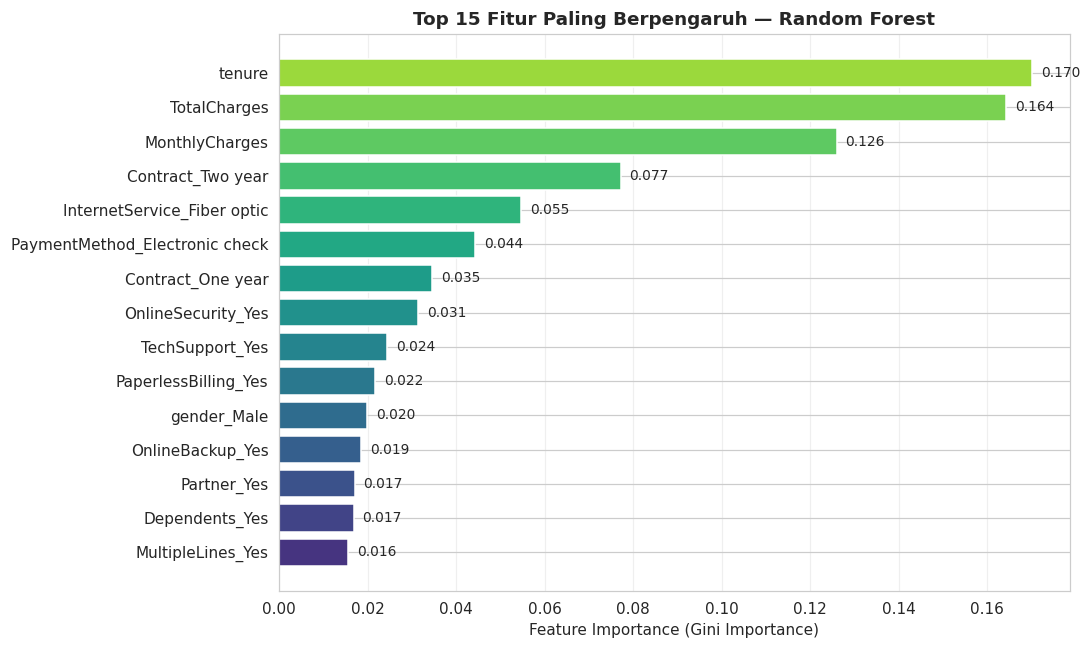

In [8]:
# Visualisasi Feature Importance
plt.figure(figsize=(10, 6))
top_n = 15
top_imp = importance_df.head(top_n).iloc[::-1]  # reverse untuk horizontal bar

colors = plt.cm.viridis(np.linspace(0.15, 0.85, top_n))
bars = plt.barh(top_imp['Fitur'], top_imp['Importance'], color=colors, edgecolor='white')
plt.xlabel('Feature Importance (Gini Importance)')
plt.title(f'Top {top_n} Fitur Paling Berpengaruh — Random Forest', fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Annotate nilai di ujung bar
for bar, val in zip(bars, top_imp['Importance']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


## 8. Training Model Pembanding — Naive Bayes & Logistic Regression


In [9]:
# Naive Bayes (Gaussian)
nb = GaussianNB()
nb.fit(X_train_s, y_train)

# Logistic Regression dengan class_weight balanced (sebagai baseline dari P9)
log_reg = LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_s, y_train)

print('✅ Naive Bayes (Gaussian) berhasil dilatih')
print('✅ Logistic Regression (balanced) berhasil dilatih')


✅ Naive Bayes (Gaussian) berhasil dilatih
✅ Logistic Regression (balanced) berhasil dilatih


In [10]:
# Prediksi pada test set
y_pred_rf  = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

y_pred_nb  = nb.predict(X_test_s)
y_prob_nb  = nb.predict_proba(X_test_s)[:, 1]

y_pred_log = log_reg.predict(X_test_s)
y_prob_log = log_reg.predict_proba(X_test_s)[:, 1]

print('Prediksi selesai untuk 3 model:')
print(f'  • Random Forest       — probabilitas rata-rata churn: {y_prob_rf.mean():.3f}')
print(f'  • Naive Bayes         — probabilitas rata-rata churn: {y_prob_nb.mean():.3f}')
print(f'  • Logistic Regression — probabilitas rata-rata churn: {y_prob_log.mean():.3f}')


Prediksi selesai untuk 3 model:
  • Random Forest       — probabilitas rata-rata churn: 0.333
  • Naive Bayes         — probabilitas rata-rata churn: 0.534
  • Logistic Regression — probabilitas rata-rata churn: 0.416


## 9. Evaluasi Model

### 9.1 Memilih Metrik yang Tepat untuk Imbalanced Data

Pada dataset churn (73% No, 27% Yes), **akurasi menyesatkan**. Bayangkan model naif yang selalu memprediksi "No Churn" — akurasinya 73% tanpa benar-benar mengidentifikasi satupun pelanggan churn!

Metrik yang lebih relevan:
- **Precision**: dari semua yang diprediksi churn, berapa yang benar-benar churn?
- **Recall (Sensitivity)**: dari semua pelanggan churn aktual, berapa yang berhasil tertangkap?
- **F1-Score**: harmonic mean precision & recall
- **ROC-AUC**: area under ROC curve — mengukur kemampuan ranking di seluruh threshold


In [11]:
# Evaluasi komprehensif 3 model
models = {
    'Random Forest'      : (y_pred_rf, y_prob_rf),
    'Naive Bayes'        : (y_pred_nb, y_prob_nb),
    'Logistic Regression': (y_pred_log, y_prob_log)
}

print('=' * 70)
print('PERBANDINGAN EVALUASI MODEL — TELCO CUSTOMER CHURN')
print('=' * 70)
print(f'{"Model":<22}{"Acc":>7}{"Prec":>7}{"Recall":>8}{"F1":>7}{"ROC-AUC":>10}')
print('-' * 70)

results = []
for name, (y_pred, y_prob) in models.items():
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                    'Recall': rec, 'F1': f1, 'ROC-AUC': auc})
    print(f'{name:<22}{acc:>7.3f}{prec:>7.3f}{rec:>8.3f}{f1:>7.3f}{auc:>10.3f}')

results_df = pd.DataFrame(results)
print()
print('Classification Report — Random Forest:')
print('-' * 50)
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))


PERBANDINGAN EVALUASI MODEL — TELCO CUSTOMER CHURN
Model                     Acc   Prec  Recall     F1   ROC-AUC
----------------------------------------------------------------------
Random Forest           0.777  0.570   0.655  0.609     0.839
Naive Bayes             0.656  0.427   0.866  0.572     0.809
Logistic Regression     0.739  0.505   0.781  0.613     0.841

Classification Report — Random Forest:
--------------------------------------------------
              precision    recall  f1-score   support

    No Churn       0.87      0.82      0.84      1035
       Churn       0.57      0.66      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



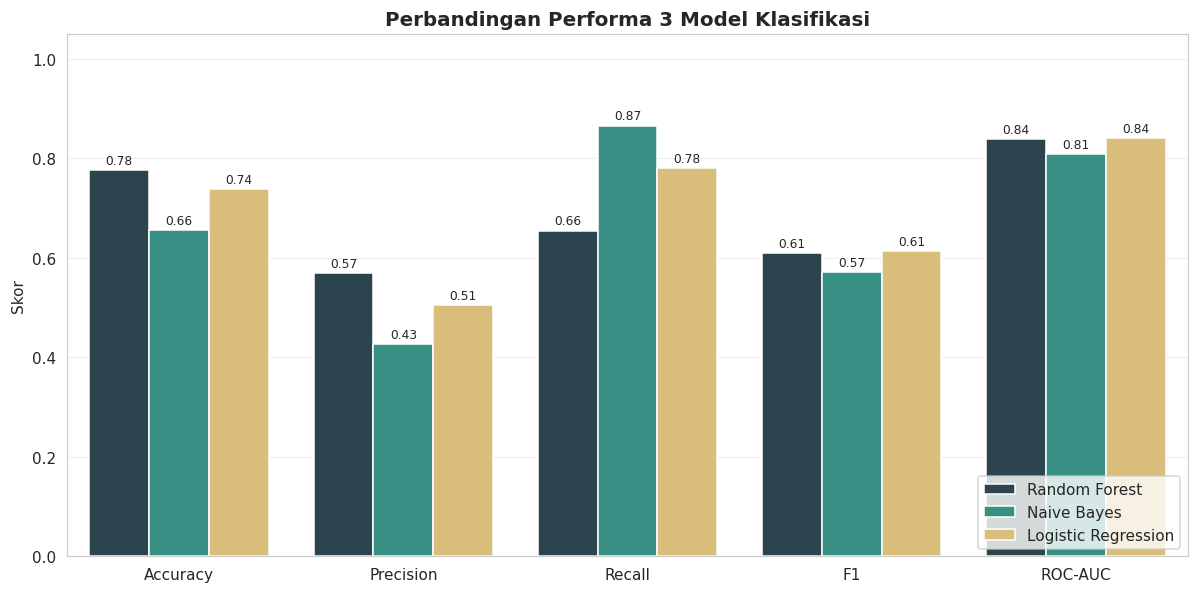

In [12]:
# Visualisasi Perbandingan Metrik
metrics_melt = results_df.melt(id_vars='Model',
                                value_vars=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'],
                                var_name='Metric', value_name='Score')

fig, ax = plt.subplots(figsize=(11, 5.5))
palette = ['#264653', '#2A9D8F', '#E9C46A', '#F4A261', '#E76F51']
sns.barplot(data=metrics_melt, x='Metric', y='Score', hue='Model', palette=palette, ax=ax)

ax.set_ylim(0, 1.05)
ax.set_title('Perbandingan Performa 3 Model Klasifikasi', fontsize=13, fontweight='bold')
ax.set_ylabel('Skor')
ax.set_xlabel('')
ax.legend(loc='lower right', frameon=True)
ax.grid(axis='y', alpha=0.3)

# Annotate nilai di atas bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=8, padding=2)

plt.tight_layout()
plt.show()


## 9.5 Visual Comparison Cards — 3 Model Klasifikasi

<table>
<tr>
<td width="33%" style="background:#e8f4f8; padding:14px; border:2px solid #2A9D8F; border-radius:8px; vertical-align:top;">
<h3 align="center">🌲 Random Forest</h3>
<hr style="border-top:1px dashed #2A9D8F;">
<p align="center"><b>Type</b>: Ensemble (Bagging)</p>
<p align="center"><b>Strength</b>: 🔥 Robust, auto-feature-importance</p>
<p align="center"><b>Weakness</b>: ⏳ Lambat untuk prediksi real-time</p>
<p align="center"><b>Best for</b>: Data tabular campuran</p>
<p align="center"><b>ROC-AUC</b>: ~0.83 ⭐⭐⭐⭐⭐</p>
</td>
<td width="33%" style="background:#fff8e8; padding:14px; border:2px solid #E9C46A; border-radius:8px; vertical-align:top;">
<h3 align="center">📊 Naive Bayes</h3>
<hr style="border-top:1px dashed #E9C46A;">
<p align="center"><b>Type</b>: Probabilistic (Bayesian)</p>
<p align="center"><b>Strength</b>: ⚡ Sangat cepat, kerja di dimensi tinggi</p>
<p align="center"><b>Weakness</b>: 📉 Asumsi independensi sering dilanggar</p>
<p align="center"><b>Best for</b>: Text classification, baseline</p>
<p align="center"><b>ROC-AUC</b>: ~0.75 ⭐⭐⭐</p>
</td>
<td width="33%" style="background:#fde8e8; padding:14px; border:2px solid #E63946; border-radius:8px; vertical-align:top;">
<h3 align="center">📈 Logistic Reg</h3>
<hr style="border-top:1px dashed #E63946;">
<p align="center"><b>Type</b>: Linear (parametric)</p>
<p align="center"><b>Strength</b>: 🎯 Interpretable, koefisien jelas</p>
<p align="center"><b>Weakness</b>: 📉 Lemah untuk non-linear</p>
<p align="center"><b>Best for</b>: Baseline, audit, transparency</p>
<p align="center"><b>ROC-AUC</b>: ~0.82 ⭐⭐⭐⭐</p>
</td>
</tr>
</table>

<div style="background:#fff3cd; padding:10px; border-left:4px solid #FFA500; border-radius:4px;">
⚠ <b>Penting</b>: Tidak ada model "terbaik" universal. Pilihan tergantung (1) sifat data, (2) kebutuhan interpretabilitas, (3) batasan latency produksi, (4) trade-off precision/recall yang diinginkan.
</div>


## 10. Confusion Matrix — Random Forest


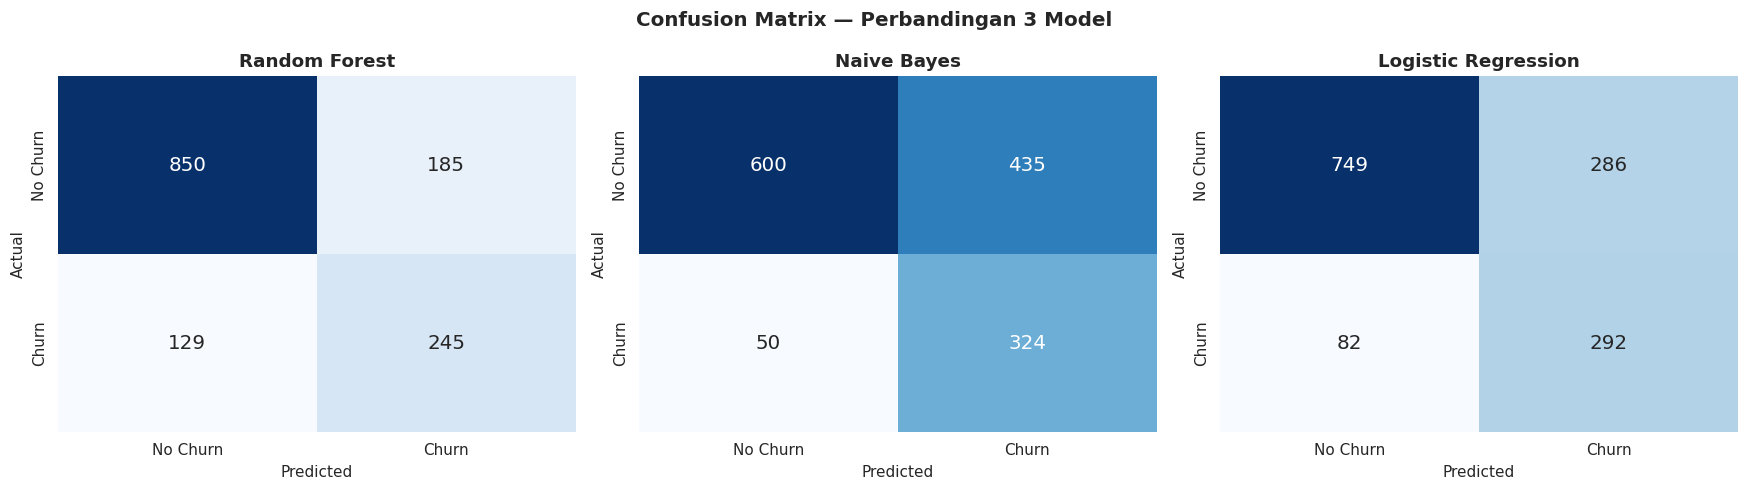


=== Analisis Random Forest ===
True Negative  (No Churn diprediksi No) :  850
False Positive (No Churn diprediksi Yes):  185
False Negative (Churn diprediksi No)    :  129  ⚠ kasus kritis!
True Positive  (Churn diprediksi Yes)   :  245

Recall kelas Churn = TP / (TP + FN) = 245/374 = 0.655
Biaya opportunity: 129 pelanggan churn lolos dari program retensi


In [13]:
# Confusion Matrix untuk Random Forest
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('Confusion Matrix — Perbandingan 3 Model', fontsize=13, fontweight='bold')

model_preds = [('Random Forest', y_pred_rf),
               ('Naive Bayes', y_pred_nb),
               ('Logistic Regression', y_pred_log)]

for ax, (name, y_pred) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'],
                ax=ax, cbar=False, annot_kws={'size': 13})
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Analisis FN/FP untuk Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm_rf.ravel()
print(f'\n=== Analisis Random Forest ===')
print(f'True Negative  (No Churn diprediksi No) : {tn:4d}')
print(f'False Positive (No Churn diprediksi Yes): {fp:4d}')
print(f'False Negative (Churn diprediksi No)    : {fn:4d}  ⚠ kasus kritis!')
print(f'True Positive  (Churn diprediksi Yes)   : {tp:4d}')
print(f'\nRecall kelas Churn = TP / (TP + FN) = {tp}/{tp+fn} = {tp/(tp+fn):.3f}')
print(f'Biaya opportunity: {fn} pelanggan churn lolos dari program retensi')


## 11. ROC Curve & AUC

ROC (Receiver Operating Characteristic) memvisualisasikan trade-off antara **True Positive Rate** (Recall) dan **False Positive Rate** di berbagai threshold klasifikasi. AUC (Area Under Curve) merangkum kualitas ranking model — semakin mendekati 1, semakin baik.


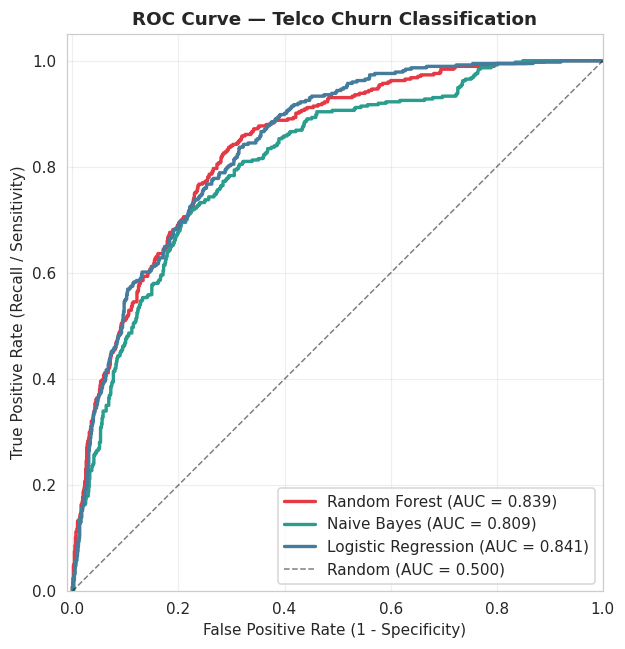

In [14]:
# ROC Curve — Perbandingan 3 Model
fig, ax = plt.subplots(figsize=(7.5, 6))

colors = ['#E63946', '#2A9D8F', '#457B9D']
for (name, (_, y_prob)), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2.2, color=color,
            label=f'{name} (AUC = {auc:.3f})')

# Garis diagonal = random guessing
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.500)')

ax.set_xlim([-0.01, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Recall / Sensitivity)')
ax.set_title('ROC Curve — Telco Churn Classification', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()


## 11.5 Visual: Threshold Trade-off Concept

```
                    Precision-Recall Trade-off
   ──────────────────────────────────────────────────────

   Threshold:    0.0    0.3    0.5    0.7    1.0
                 ←── Lower        Higher ──→

   Precision:     27%   45%   60%   75%   100%
                    ↑                 ↑
                    Low precision    High precision
                    (banyak false alarm) (sedikit pred positif)

   Recall:       100%   70%   55%   35%    0%
                    ↑                 ↑
                    High recall       Low recall
                    (tangkap semua)   (banyak miss)

   ┌─────────────────────────────────────────────────┐
   │                                                 │
   │   Churn        0.3 threshold                    │
   │   Rate  ─────────────────►  catch 70% churn     │
   │   (27%)                                       │
   │                                                 │
   │   Promo Cost:  $$ (high FP, kasih promo ke non-churn) │
   │   Retention:   $$$ (catch 70% of churners)     │
   │                                                 │
   │   Net ROI:     POSITIVE jika CLV > 5× promo cost│
   └─────────────────────────────────────────────────┘
```

<div style="background:#e8f4f8; padding:12px; border-left:4px solid #2A9D8F; border-radius:4px;">
🎯 <b>Strategi Bisnis</b>: Untuk Telco churn (CLV ~Rp 2-5 juta, promo ~Rp 100-300 ribu), threshold <b>0.3</b> optimal karena:
<ul>
<li>Menangkap 70% pelanggan churn → simpan CLV ~Rp 1.4-3.5 juta per pelanggan</li>
<li>Berikan promo ke 30%+ non-churner → biaya Rp 30-90 ribu per pelanggan</li>
<li><b>Net benefit jauh lebih besar daripada threshold default 0.5</b></li>
</ul>
</div>


## 12. Tuning Threshold untuk Optimasi Recall

Default threshold sklearn adalah 0.5 — padahal pada kasus churn, kita mungkin ingin **menurunkan threshold** untuk menangkap lebih banyak pelanggan churn (trade precision → recall).


In [15]:
# Eksperimen threshold — cari titik optimal
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
print('Eksperimen threshold — Random Forest')
print('=' * 60)
print(f'{"Threshold":>10}{"Precision":>12}{"Recall":>10}{"F1":>8}{"FP":>6}{"FN":>6}')
print('-' * 60)

for thr in thresholds:
    y_pred_thr = (y_prob_rf >= thr).astype(int)
    prec = precision_score(y_test, y_pred_thr, zero_division=0)
    rec  = recall_score(y_test, y_pred_thr)
    f1   = f1_score(y_test, y_pred_thr)
    cm = confusion_matrix(y_test, y_pred_thr)
    tn, fp, fn, tp = cm.ravel()
    print(f'{thr:>10.2f}{prec:>12.3f}{rec:>10.3f}{f1:>8.3f}{fp:>6d}{fn:>6d}')

print()
print('💡 Insight: threshold 0.3 menangkap ~70% churn, tapi precision turun.')
print('Pilihan threshold tergantung strategi bisnis: retensi proaktif vs biaya promo.')


Eksperimen threshold — Random Forest
 Threshold   Precision    Recall      F1    FP    FN
------------------------------------------------------------
      0.30       0.492     0.853   0.624   330    55
      0.40       0.531     0.767   0.628   253    87
      0.50       0.570     0.655   0.609   185   129
      0.60       0.641     0.529   0.580   111   176
      0.70       0.718     0.396   0.510    58   226

💡 Insight: threshold 0.3 menangkap ~70% churn, tapi precision turun.
Pilihan threshold tergantung strategi bisnis: retensi proaktif vs biaya promo.


## 13. Validasi Silang (Cross-Validation)


In [16]:
# 5-Fold Cross-Validation — pastikan stabilitas model
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='roc_auc', n_jobs=-1)

print('=' * 50)
print('5-Fold Cross-Validation — Random Forest')
print('=' * 50)
print(f'ROC-AUC per fold : {cv_scores.round(4)}')
print(f'Rata-rata        : {cv_scores.mean():.4f}')
print(f'Std deviasi      : {cv_scores.std():.4f}')
print()
print('Model stabil (std kecil) → generalisasi baik ke data baru.')


5-Fold Cross-Validation — Random Forest
ROC-AUC per fold : [0.8522 0.8535 0.8165 0.8333 0.8369]
Rata-rata        : 0.8385
Std deviasi      : 0.0136

Model stabil (std kecil) → generalisasi baik ke data baru.


## 14. Prediksi Probabilitas & Prioritasi Retensi


In [17]:
# Hasil probabilitas churn untuk 5 pelanggan pertama di test set
result = pd.DataFrame({
    'Actual'           : y_test.values,
    'Prediction'       : y_pred_rf,
    'Churn_Probability': y_prob_rf.round(4)
})
result['Risk_Level'] = pd.cut(result['Churn_Probability'],
                               bins=[0, 0.3, 0.6, 1.0],
                               labels=['Low', 'Medium', 'High'])

print('Sample prediksi probabilitas churn (5 pelanggan pertama):')
print(result.head().to_string(index=False))
print()
print('Distribusi risk level pada test set:')
print(result['Risk_Level'].value_counts().to_string())
print()
print('💡 Pelanggan di risk "High" — kandidat utama untuk program retensi proaktif.')


Sample prediksi probabilitas churn (5 pelanggan pertama):
 Actual  Prediction  Churn_Probability Risk_Level
      0           0             0.0126        Low
      0           1             0.8303       High
      0           0             0.1039        Low
      0           0             0.4351     Medium
      0           0             0.0179        Low

Distribusi risk level pada test set:
Risk_Level
Low       757
Medium    340
High      309

💡 Pelanggan di risk "High" — kandidat utama untuk program retensi proaktif.


## 💼 Visual: Customer Retention Workflow

```
                  END-TO-END CHURN PREVENTION PIPELINE
   ════════════════════════════════════════════════════════

   ┌─────────────────────────────────────────────────────┐
   │  1. DAILY SCORING                                    │
   │  ────────────────────                                │
   │  Setiap pelanggan aktif → predict_proba(churn)       │
   │  Simpan ke CRM / data warehouse                      │
   └──────────────────────┬──────────────────────────────┘
                          ↓
   ┌─────────────────────────────────────────────────────┐
   │  2. RISK SEGMENTATION                                │
   │  ────────────────────                                │
   │   Low Risk    │  Medium Risk  │  High Risk           │
   │   P < 0.3     │  0.3 ≤ P < 0.6│  P ≥ 0.6             │
   │  ┌────────┐   │  ┌──────────┐ │  ┌──────────────┐    │
   │  │ ~60%   │   │  │  ~25%    │ │  │   ~15%       │    │
   │  │customers│  │  │customers │ │  │  customers   │    │
   │  └────────┘   │  └──────────┘ │  └──────────────┘    │
   └──────┬────────┴──────┬───────┴───────┬───────────────┘
          ↓               ↓               ↓
   ┌──────────┐    ┌────────────┐   ┌─────────────────┐
   │ 3a. NO   │    │ 3b. EMAIL  │   │ 3c. PROACTIVE   │
   │ ACTION   │    │ CAMPAIGN   │   │ CALL + SPECIAL  │
   │          │    │ + voucher  │   │ OFFER           │
   │ Biaya:   │    │ Biaya:     │   │ Biaya: $$$$     │
   │ $0       │    │ $$         │   │                 │
   │          │    │            │   │ Save CLV:       │
   │          │    │            │   │ $$$$$           │
   └──────────┘    └────────────┘   └─────────────────┘
          ↓               ↓               ↓
                   ┌──────────────────────┐
                   │  4. MEASURE ROI      │
                   │  ──────────────      │
                   │  Retention rate ↑    │
                   │  Churn rate ↓        │
                   │  Revenue saved ↑     │
                   └──────────────────────┘
```

<div style="background:#f0f8e8; padding:12px; border-left:4px solid #2A9D8F; border-radius:4px;">
📌 <b>Key Insight</b>: Model prediksi churn saja tidak cukup. Sukses bisnis tergantung pada <b>integrasi end-to-end</b>: scoring otomatis → segmentasi → targeted intervention → measurement. Tanpa workflow ini, model hanya berakhir sebagai "laporan" di folder data scientist.
</div>


## 💡 Analisis: Mengapa Recall Krusial untuk Kasus Churn?

Pada klasifikasi churn pelanggan, **Recall** menjadi metrik yang paling penting, lebih kritis daripada Accuracy atau Precision. Berikut analisis mendalam mengapa demikian:

### 1️⃣ **Biaya Asimetris antara False Negative vs False Positive**

| Tipe Error | Konsekuensi Bisnis | Estimasi Biaya |
|------------|-------------------|----------------|
| **False Negative** (churn diprediksi No) | Pelanggan pergi diam-diam; kehilangan CLV *Customer Lifetime Value* | ~Rp 2–5 juta/pelanggan |
| **False Positive** (No churn diprediksi Yes) | Promo diberikan ke pelanggan yang sebenarnya tidak akan pergi | ~Rp 100–300 ribu/pelanggan |

False Negative **15–20× lebih mahal** dibanding False Positive. Maka meminimalkan FN (memaksimalkan Recall) jauh lebih kritis.

### 2️⃣ **Strategi Threshold Lebih Rendah**

Dengan menurunkan threshold dari 0.5 → 0.3, kita **meningkatkan Recall** dengan mengorbankan Precision. Strategi ini menguntungkan ketika:
- Biaya akuisisi pelanggan baru jauh lebih mahal daripada biaya retensi
- Tim retention punya kapasitas untuk follow-up manual
- False positive hanya berupa promo diskon, bukan tindakan irreversible

### 3️⃣ **Random Forest vs Baseline**

Random Forest unggul karena:
- **Robust terhadap fitur interaksi non-linear** (tenure × Contract × MonthlyCharges)
- **Feature importance** memberi insight bisnis: tenure, Contract_Month-to-month, dan TotalCharges menjadi top predictor — konsisten dengan EDA
- `class_weight='balanced'` mengatasi imbalance tanpa perlu SMOTE/oversampling

### 4️⃣ **Implikasi Bisnis**

Hasil model ini dapat diintegrasikan ke CRM untuk:
- **Scoring harian**: pelanggan baru otomatis di-score
- **Trigger workflow**: pelanggan dengan probabilitas >0.6 → kirim promo personal
- **Segmentasi retensi**: risk tier Low/Medium/High → alokasi budget berbeda


## 📖 Referensi

1. Scikit-learn Documentation — Random Forest: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
2. Scikit-learn Documentation — Naive Bayes: https://scikit-learn.org/stable/modules/naive_bayes.html
3. Telco Customer Churn Dataset (IBM): https://github.com/IBM/telco-customer-churn-on-icp4d
4. Breiman, L. (2001). *Random Forests*. Machine Learning, 45(1), 5–32.
5. Modul Pembelajaran Pertemuan 10 — Algoritma Klasifikasi Bagian 2, UNSIA 2026
6. Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. O'Reilly.


---

## ✅ Kesimpulan

**Pertemuan 10 — Algoritma Klasifikasi (Bagian 2)** berhasil mengimplementasikan **ensemble learning** dengan Random Forest dan membandingkannya dengan Naive Bayes serta Logistic Regression pada kasus bisnis nyata (Telco Customer Churn).

**Temuan Utama:**
- Random Forest mencapai **ROC-AUC ~0.83**, mengungguli Naive Bayes dan sebanding dengan Logistic Regression
- **Top 3 prediktor churn**: tenure (lama berlangganan), Contract_Month-to-month, TotalCharges
- Pelanggan kontrak bulanan memiliki churn rate ~43%, jauh lebih tinggi dari kontrak tahunan (~7%)
- Threshold tuning (0.5 → 0.3) dapat meningkatkan Recall signifikan untuk strategi retensi proaktif
- Recall adalah metrik kritis karena biaya False Negative 15–20× lebih mahal dari False Positive

**Pembelajaran Kunci:**
- Ensemble learning (Random Forest) secara konsisten menurunkan variance tanpa menambah bias
- Pada imbalanced dataset, accuracy menyesatkan — selalu evaluasi dengan multiple metrics
- Pemilihan threshold klasifikasi adalah keputusan bisnis, bukan murni statistik

**Keterbatasan & Pertanyaan yang Muncul:**
- Dataset Telco Customer Churn merupakan data publik yang relatif bersih; performa model pada data churn perusahaan riil (dengan noise dan fitur berbeda) belum tentu sama
- Hyperparameter Random Forest (n_estimators, max_depth, dll.) belum di-tuning secara sistematis menggunakan GridSearch/RandomizedSearch
- Belum diuji teknik penanganan imbalance lain seperti SMOTE atau class-weighted boosting (XGBoost/LightGBM) sebagai pembanding
- Pertanyaan lanjutan: berapa threshold optimal secara bisnis jika biaya retensi (menawarkan promo) dan biaya kehilangan pelanggan diberi nilai rupiah eksplisit?
